In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from IPython.display import display, Markdown

mpl.rcParams['font.size'] = 16

In [2]:
def read_file(filename, total_comps):
    with open(filename) as f:
        time, ops, nhits = [], [], []
        for line in f:
            line =  line.rstrip().lstrip()
            if not line:
                continue

            temp = line.split()
            if len(temp) > 5:
                time.append(float(temp[6]))
                ops.append((int(temp[7])/total_comps)*100)
                nhits.append(int(temp[1]))
            else:
                time.append(float(temp[4]))
                

    return time, ops, nhits

def read_fpsim2_file(filename):
    with open(filename) as f:
        time, nhits = [], []
        for line in f:
            line =  line.rstrip().lstrip()
            if not line:
                continue

            temp = line.split()
            time.append(float(temp[6]))
            nhits.append(int(temp[1]))

    return time, nhits    

def plot_ops_violin(data, ylabel, output, y_log=False, showextrema=False):
    fig = plt.figure(figsize=(10, 6))
    ax1 = fig.add_subplot(111)
    ax1.violinplot(data.values(), showextrema=showextrema, showmeans=True)
    ax1.set_xticks(range(1, 13), get_violin_labels(), rotation="vertical")
    if y_log:
        ax1.set_yscale("log")
    ax1.set_xlabel('Threshold/top-K')
    #ax1.set_xlim(0, 90)
    ax1.set_ylabel(ylabel)
    if y_log:
        ax1.set_ylim(bottom=1)
    else:
        ax1.set_ylim(bottom=0)
    
    fig.tight_layout()
    fig.savefig(f'{output}.png', dpi=300)
    
    plt.show()
    
def get_violin_labels():
    labels = []
    for d in range(5, 8):
        for k in [1, 10, 100, 1000]:
            labels.append(f"{d/10:.1f}/{k}")
    return labels
    
def percentiles(data):
    return np.percentile(data, 99), np.percentile(data, 90), np.percentile(data, 75), np.percentile(data, 50), np.percentile(data, 25)

In [3]:
times_percentile_data = {}
times_data = {}
ops_data = {}
nhits_data = {}
fpsim2_times_data = {}

#times_percentile_data["FPSim2"] = percentiles(times)
for d in range(5, 8):
    for k in [1, 10, 100, 1000]:
        fpsim2_times, nhits = read_fpsim2_file(f"../../fpsim2_benchmark/topk/benchmark_b512_{d}_{k}.log")
        fpsim2_times_data[(d,k)] = fpsim2_times
        times, ops, nhits = read_file(f"benchmark_{d}_{k}.log", 2474590.0)
        times_percentile_data[(d,k)] = percentiles(times)
        ops_data[(d,k)] = ops
        times_data[(d,k)] = times
        nhits_data[(d,k)] = nhits

In [4]:
header = ["cut-off", "K", "99%", "90%", "75%", "50%", "25%"]
with open("benchmark_b512_topk.csv", "w") as fin:
    fin.write(",".join(header))
    fin.write("\n")
    for key, value in times_percentile_data.items():
        fin.write(f"{key[0]/10},{key[1]},")
        fin.write(",".join(map(lambda x: f'{x:.2f}',value)))
        fin.write("\n")

In [5]:
with open("fpsim2_benchmark_b512_topk.csv", "w") as fin:
    fin.write(",".join(header))
    fin.write("\n")
    for key, value in fpsim2_times_data.items():
        fin.write(f"{key[0]/10},{key[1]},")
        pvalues = percentiles(value)
        fin.write(",".join(map(lambda x: f'{x:.2f}',pvalues)))
        fin.write("\n")

In [7]:
with open("speedup_benchmark_b512_topk.csv", "w") as fin:
    fin.write(",".join(header))
    fin.write("\n")
    for key, value in fpsim2_times_data.items():
        fin.write(f"{key[0]/10},{key[1]},")
        fpsim2_values = np.array(percentiles(value))
        uffpsim_values = np.array(times_percentile_data[key])
        factor = fpsim2_values/uffpsim_values
        fin.write(",".join(map(lambda x: f'{x:.0f}',factor)))
        fin.write("\n")

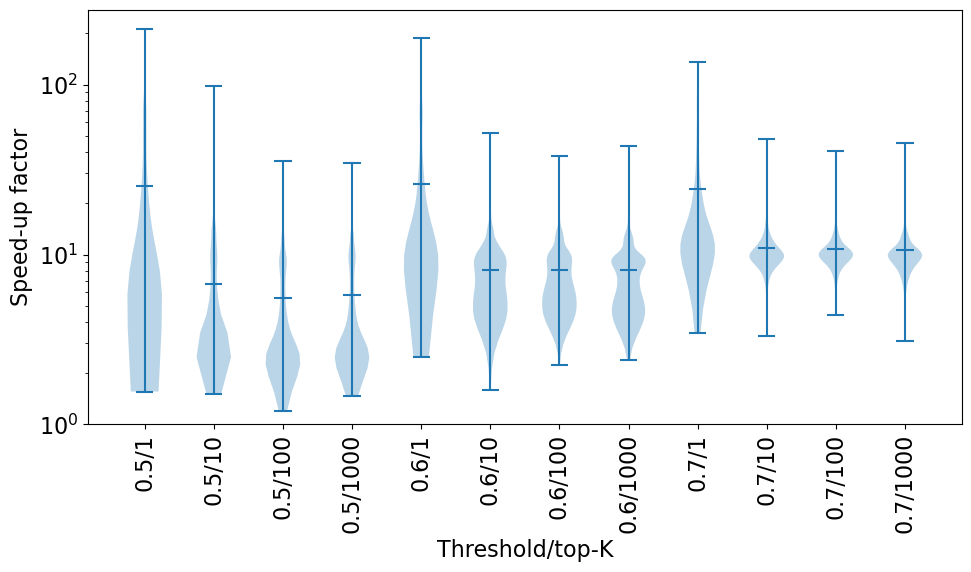

In [8]:
performance_gains = {}
for d in range(5, 8):
    for k in [1, 10, 100, 1000]:
        gain = []
        for t_fpsim2, t_uffpsim in zip(fpsim2_times_data[(d,k)], times_data[(d,k)]):
            gain.append(t_fpsim2/t_uffpsim)

        performance_gains[(d/k)] = gain

plot_ops_violin(performance_gains, 'Speed-up factor', 'uffpsim_vs_fpsim2_b512', y_log=True, showextrema=True)

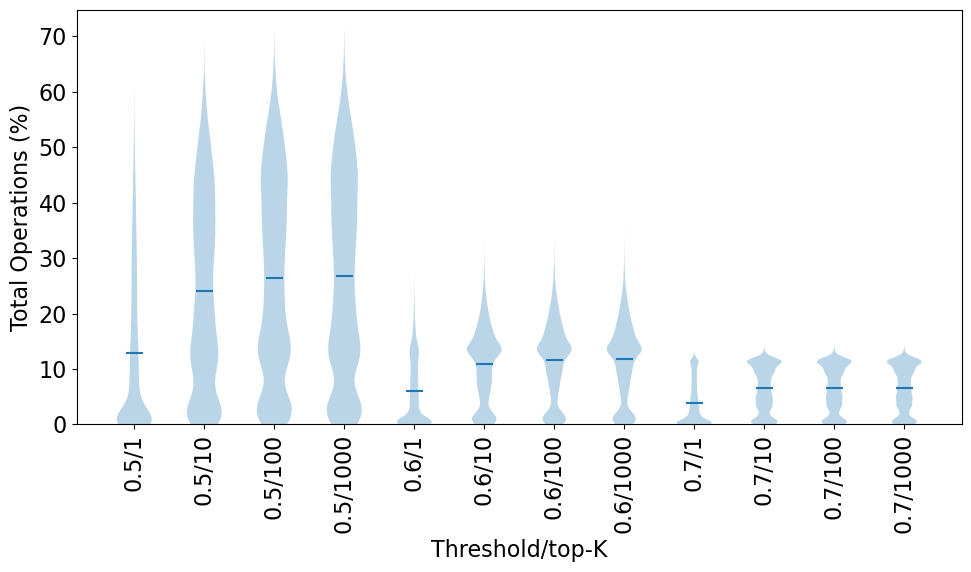

In [6]:
plot_ops_violin(ops_data, 'Total Operations (%)', 'sim-ops-vs-cutoff')

/home/raj/github/uffpsim/venv/lib/python3.11/site-packages/numpy/lib/function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/home/raj/github/uffpsim/venv/lib/python3.11/site-packages/numpy/core/fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


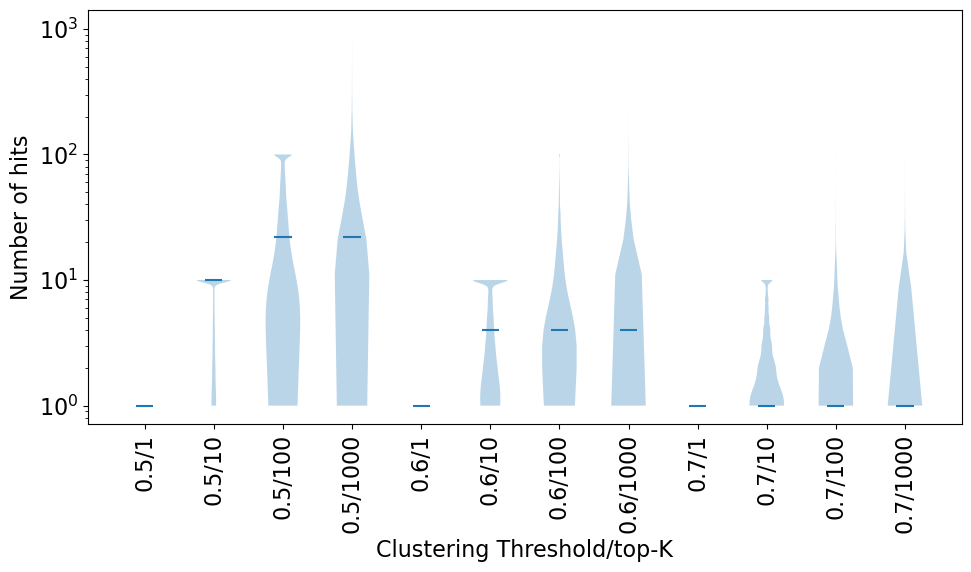

In [6]:
def plot_nhits_violin(nhits_data):
    fig = plt.figure(figsize=(10, 6))
    ax1 = fig.add_subplot(111)
    array = []
    for a in nhits_data.values():
        array.append(np.ma.masked_values(np.array(a), 0))
    ax1.violinplot(array, showextrema=False, showmedians=True)
    ax1.set_xticks(range(1, 13), get_violin_labels(), rotation="vertical")
    ax1.set_yscale("log")
    ax1.set_xlabel('Clustering Threshold/top-K')
    #ax1.set_xlim(0, 90)
    ax1.set_ylabel('Number of hits')
    
    fig.tight_layout()
    fig.savefig(f'nhits-vs-cutoff.png', dpi=300)
    
    plt.show()

#print(ops_data.values())
plot_nhits_violin(nhits_data)